Sampling Frequency: 48000 Hz
Total Samples: 960000


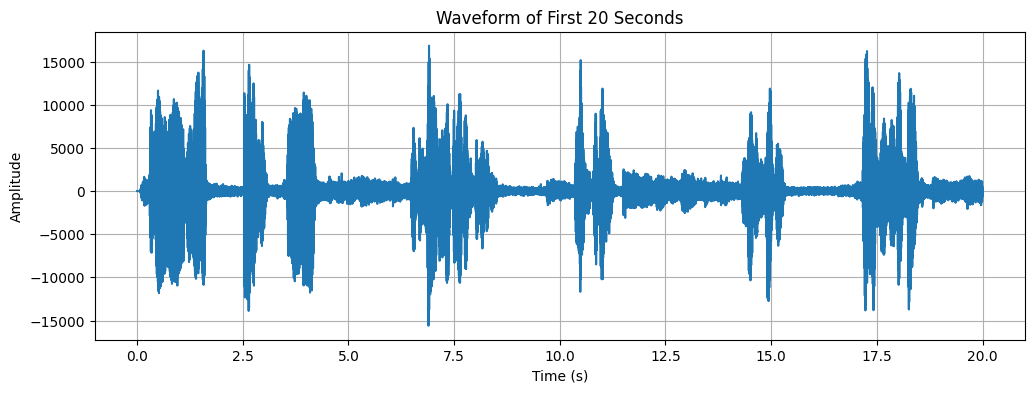

Total Number of Frames: 1998


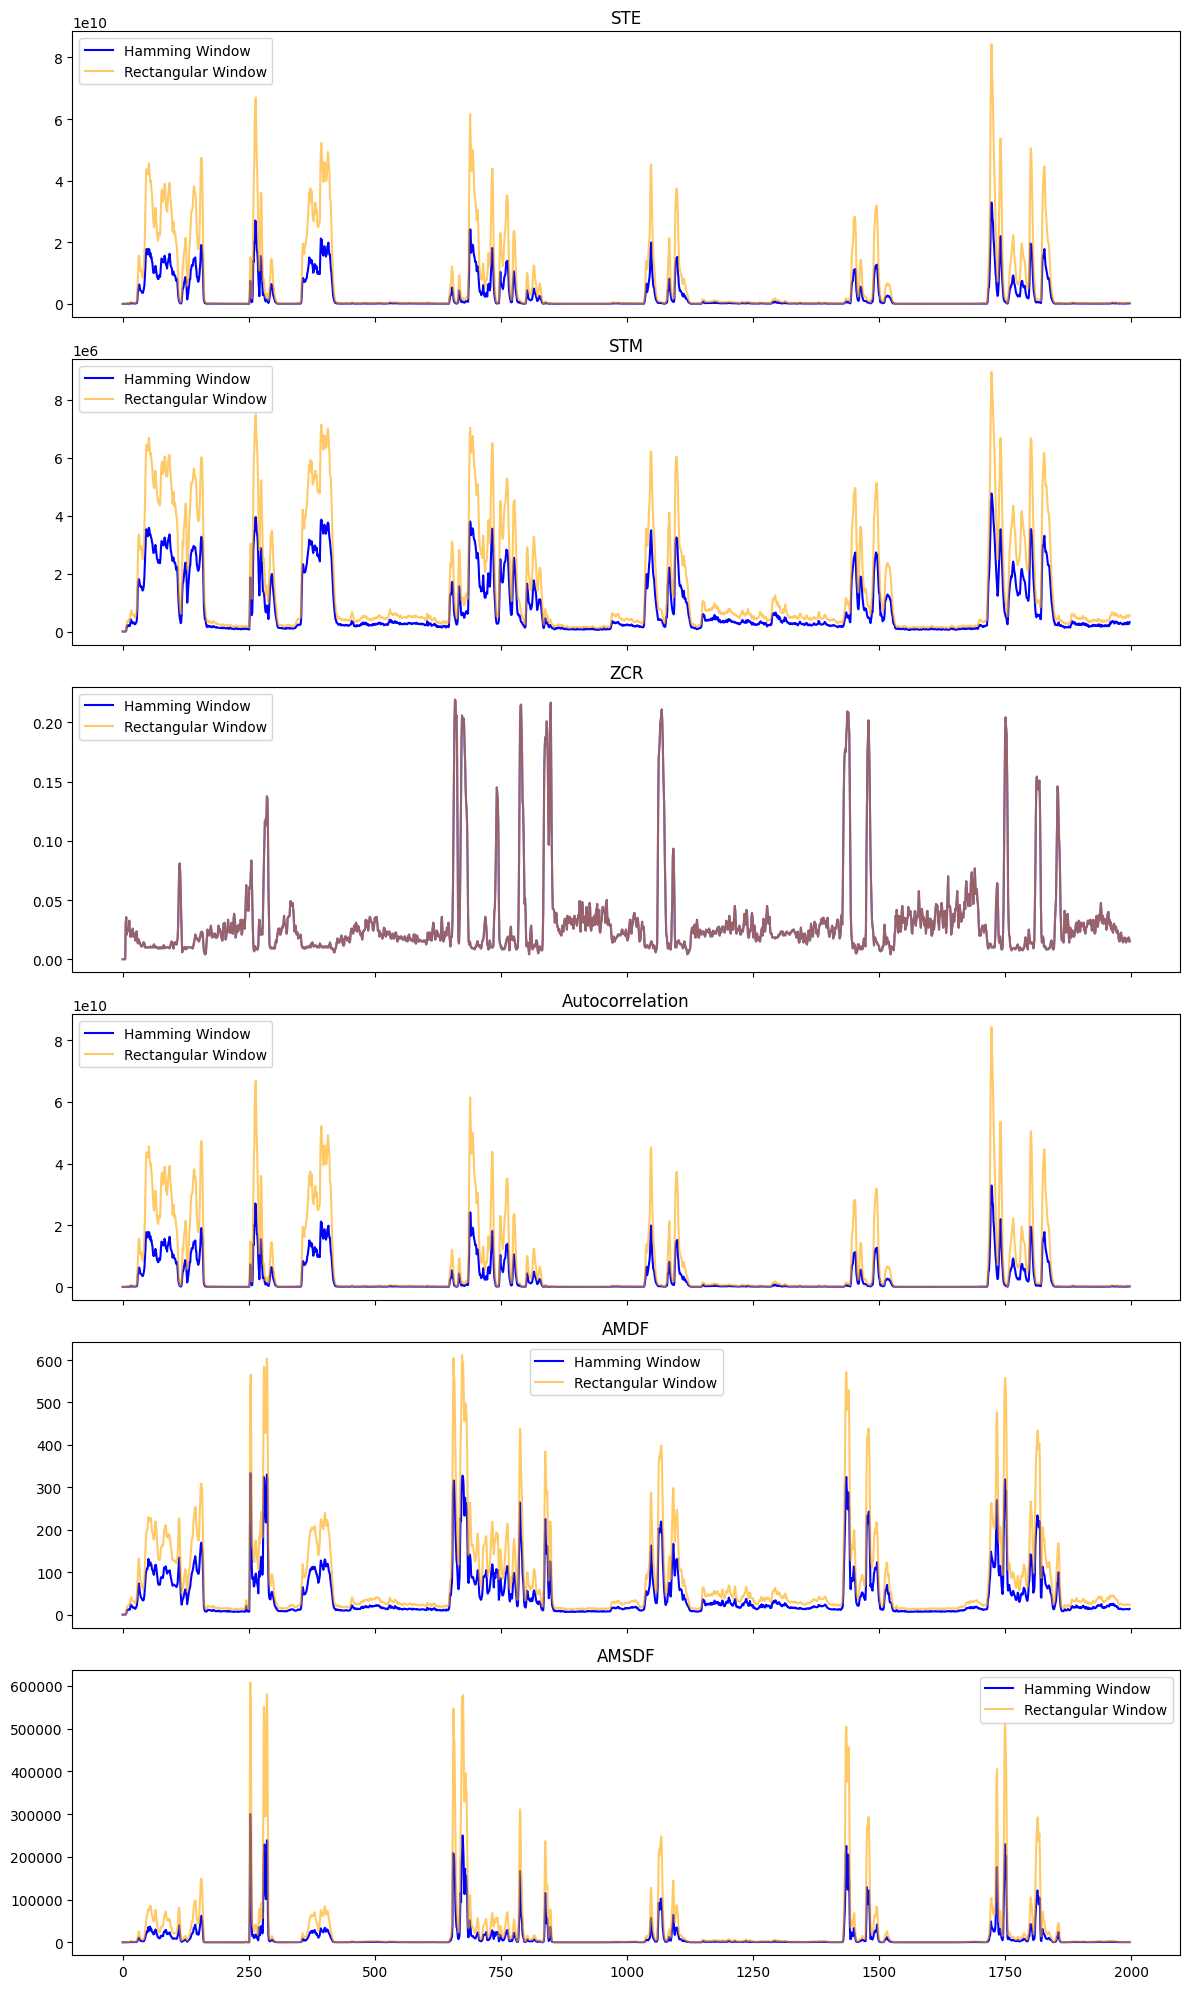

In [ ]:
import wave
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. LOAD AND VISUALIZE (Task 1a)
# ---------------------------------------------------------
file_path = 'Trevor_Slattery_Wonder_Man_therapy_scene_256KBPS.wav'

with wave.open(file_path, 'rb') as wav_file:
    sr = wav_file.getframerate() # Sampling frequency [ : 6]
    n_samples = wav_file.getnframes()
    
    # Load first 20 seconds of speech 
    duration_to_load = 20
    max_samples = int(duration_to_load * sr)
    raw_data = wav_file.readframes(min(n_samples, max_samples))
    signal = np.frombuffer(raw_data, dtype=np.int16).astype(np.float32)
    
    # Handle stereo if necessary
    if wav_file.getnchannels() > 1:
        signal = signal[0::wav_file.getnchannels()]

print(f"Sampling Frequency: {sr} Hz")
print(f"Total Samples: {len(signal)}")

# Visualize the waveform 
plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, len(signal)/sr, len(signal)), signal)
plt.title("Waveform of First 20 Seconds")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 2. FRAMING PARAMETERS (Task 1b & 1c)
# ---------------------------------------------------------
frame_len_ms = 25 # 
frame_shift_ms = 10 # 

# Convert ms to samples
frame_length = int(frame_len_ms * sr / 1000)
frame_step = int(frame_shift_ms * sr / 1000)

# Compute total number of frames 
num_frames = int(np.floor((len(signal) - frame_length) / frame_step)) + 1
print(f"Total Number of Frames: {num_frames}")

# Segment into overlapping frames 
indices = np.arange(0, num_frames * frame_step, frame_step)[:, np.newaxis] + np.arange(frame_length)
frames = signal[indices]

# ---------------------------------------------------------
# 3. FEATURE EXTRACTION (Task 1d, 1e, 1f)
# ---------------------------------------------------------
def extract_time_domain_features(frames, window_type='hamming'):
    n_f, f_len = frames.shape
    
    # Choose window function [: 12, 19]
    if window_type == 'hamming':
        win = np.hamming(f_len)
    else:
        win = np.ones(f_len) # Rectangular
        
    # Feature arrays
    ste = np.zeros(n_f)
    stm = np.zeros(n_f)
    zcr = np.zeros(n_f)
    autocorr = np.zeros(n_f)
    amdf = np.zeros(n_f)
    amsdf = np.zeros(n_f)
    
    for i in range(n_f):
        f = frames[i] * win
        
        # Short-Time Energy (STE) [ : 13]
        ste[i] = np.sum(f**2)
        
        # Short-Time Magnitude (STM) [ : 14]
        stm[i] = np.sum(np.abs(f))
        
        # Zero-Crossing Rate (ZCR) [ : 15]
        zcr[i] = np.sum(np.abs(np.diff(np.sign(f)))) / (2 * f_len)
        
        # Autocorrelation (at lag k=1) [ : 16]
        autocorr[i] = np.correlate(f, f, mode='same')[f_len//2 + 1]
        
        # AMDF (Average Magnitude Difference Function) [ : 17]
        amdf[i] = np.mean(np.abs(f[1:] - f[:-1]))
        
        # AMSDF (Average Magnitude Squared Difference Function) [ : 18]
        amsdf[i] = np.mean((f[1:] - f[:-1])**2)
        
    return ste, stm, zcr, autocorr, amdf, amsdf

# Compute for both windows
feat_ham = extract_time_domain_features(frames, 'hamming')
feat_rect = extract_time_domain_features(frames, 'rectangular')

# ---------------------------------------------------------
# 4. PLOTTING RESULTS (Task 1f)
# ---------------------------------------------------------
titles = ['STE', 'STM', 'ZCR', 'Autocorrelation', 'AMDF', 'AMSDF']
fig, axes = plt.subplots(6, 1, figsize=(12, 20), sharex=True)

for i in range(6):
    axes[i].plot(feat_ham[i], label='Hamming Window', color='blue')
    axes[i].plot(feat_rect[i], label='Rectangular Window', color='orange', alpha=0.6)
    axes[i].set_title(titles[i])
    axes[i].legend()

plt.tight_layout()
plt.show()

#1-g: Comparison of Features
#Voiced segments show high Energy (STE/STM) and low ZCR due to periodic vocal cord vibration, while unvoiced segments exhibit low energy and high ZCR because they are noise-like. Autocorrelation and AMDF/AMSDF effectively show clear peaks or minima only in voiced frames, confirming their periodicity.

#1-h: Effect of Window Choice
#The Hamming window tapers frame edges, reducing spectral leakage and producing smoother, more stable feature contours compared to the Rectangular window. This smoothing significantly improves the discrimination capability and accuracy of pitch detection by removing artificial discontinuities at frame boundaries.

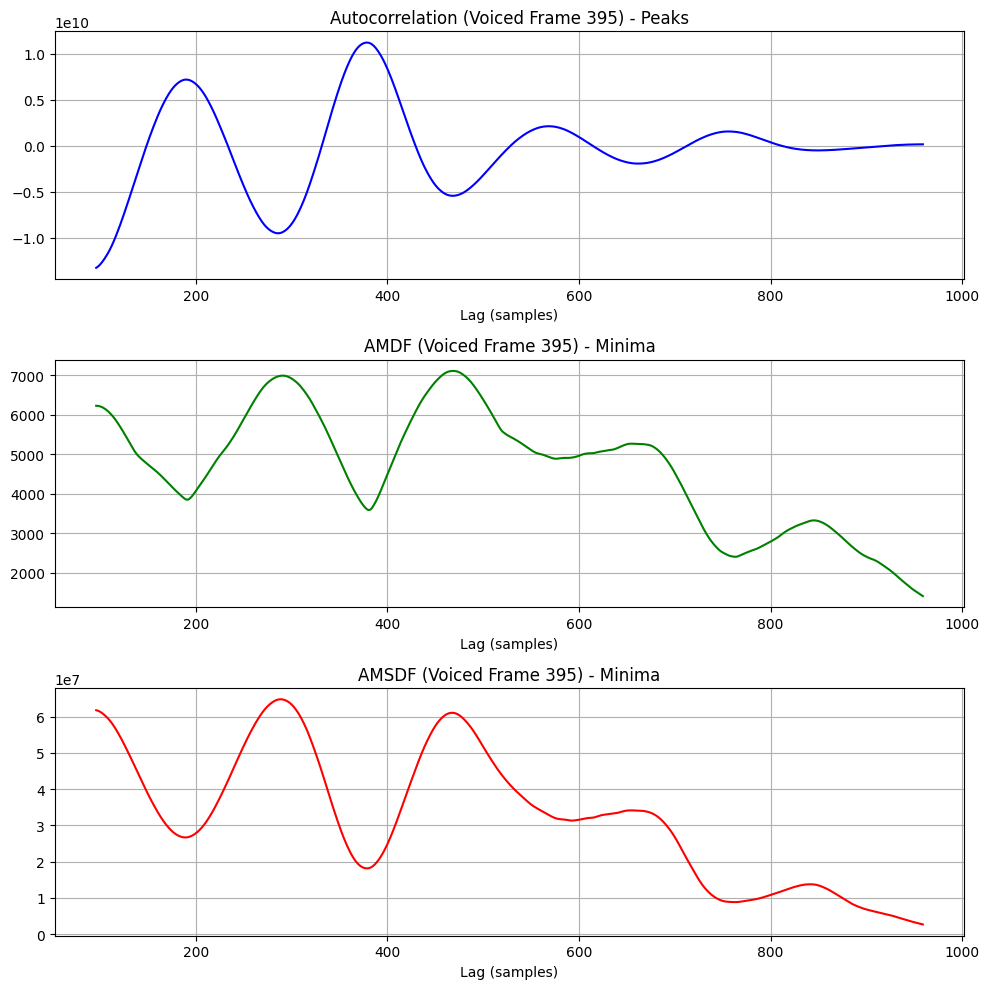

In [ ]:
def perform_task_2(frames, sr, ste, zcr):
    # DYNAMIC SELECTION: Find a frame that is definitely voiced in THIS file
    # We look for high energy (>30% of max) and low zero-crossing [ : 27, 32]
    voiced_indices = np.where((ste > 0.3 * np.max(ste)) & (zcr < 0.15))[0]
    
    if len(voiced_indices) == 0:
        print("Error: No voiced frames detected. Try a different audio segment.")
        return
        
    # Pick a frame from the middle of a voiced segment for the best periodicity
    sample_idx = voiced_indices[len(voiced_indices)//2]
    frame = frames[sample_idx] * np.hamming(len(frames[sample_idx]))
    f_len = len(frame)
    
    # Define search range for human pitch (50Hz to 500Hz) 
    min_lag, max_lag = int(sr / 500), int(sr / 50)
    lags = np.arange(min_lag, max_lag)
    
    # 1. Autocorrelation (Identify peaks) [ : 26]
    corr = np.correlate(frame, frame, mode='full')[f_len-1:]
    corr_range = corr[min_lag:max_lag]
    
    # 2. AMDF (Identify minima) [ : 26]
    amdf_values = [np.mean(np.abs(frame[k:] - frame[:-k])) for k in lags]
    
    # 3. AMSDF (Identify minima) [ : 24, 26]
    amsdf_values = [np.mean((frame[k:] - frame[:-k])**2) for k in lags]
    
    # Plotting results for Task 2b
    fig, ax = plt.subplots(3, 1, figsize=(10, 10))
    ax[0].plot(lags, corr_range, color='blue')
    ax[0].set_title(f"Autocorrelation (Voiced Frame {sample_idx}) - Peaks")
    
    ax[1].plot(lags, amdf_values, color='green')
    ax[1].set_title(f"AMDF (Voiced Frame {sample_idx}) - Minima")
    
    ax[2].plot(lags, amsdf_values, color='red')
    ax[2].set_title(f"AMSDF (Voiced Frame {sample_idx}) - Minima")
    
    for a in ax: a.grid(True); a.set_xlabel("Lag (samples)")
    plt.tight_layout()
    plt.show()

# Run Task 2 (Ensure feat_ham from Task 1 is available)
perform_task_2(frames, sr, feat_ham[0], feat_ham[2])

#2-b: Reflections of Periodicity
#Periodicity is clearly reflected as prominent peaks in the Autocorrelation function at lags corresponding to the pitch period. Conversely, AMDF and AMSDF show periodicity through deep, sharp minima (troughs) at the same lags, where the difference between the signal and its shifted version is minimized.

#2-c: Periodic (Voiced) vs. Aperiodic (Unvoiced) Frames
#Periodic frames (voiced) exhibit a repetitive structure with high-amplitude peaks in autocorrelation and distinct troughs in AMDF/AMSDF. Aperiodic frames (unvoiced/silence) lack these features, showing a rapidly decaying autocorrelation near zero lag and random, shallow fluctuations in AMDF/AMSDF without any discernible pattern.

--- Sample Voiced Frame Analysis (Frame 44) ---
Detected Pitch Period (T0): 394 samples
Computed Pitch Frequency (F0): 121.83 Hz


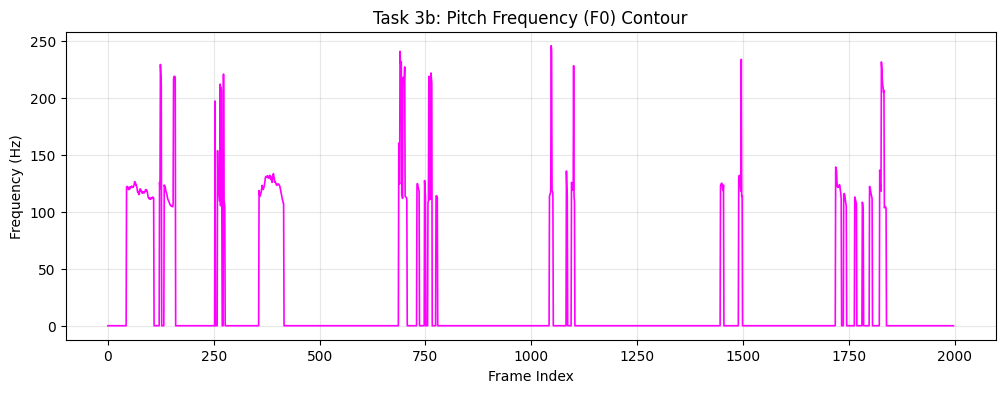

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def perform_task_3(frames, sr, ste, zcr):
    # Dynamic pitch detection range (50Hz to 500Hz)
    min_lag, max_lag = int(sr / 500), int(sr / 50)
    
    # Thresholding: Voiced frames have High Energy and Low ZCR
    energy_thresh = 0.2 * np.max(ste)
    
    pitches =  
    sample_printed = False

    for i in range(len(frames)):
        if ste[i] > energy_thresh and zcr[i] < 0.2:
            f = frames[i] * np.hamming(len(frames[i]))
            
            # Use Autocorrelation to find the pitch lag
            corr = np.correlate(f, f, mode='full')[len(f)-1:]
            corr_range = corr[min_lag:max_lag]
            
            # Determine pitch period (lag of the first prominent peak)
            pitch_lag = np.argmax(corr_range) + min_lag
            f0 = sr / pitch_lag
            pitches.append(f0)

            # Explicit output for one sample voiced frame
            if not sample_printed:
                print(f"--- Sample Voiced Frame Analysis (Frame {i}) ---")
                print(f"Detected Pitch Period (T0): {pitch_lag} samples")
                print(f"Computed Pitch Frequency (F0): {f0:.2f} Hz")
                sample_printed = True
        else:
            pitches.append(0) # Unvoiced/Silence
            
    return np.array(pitches)

# Execute extraction and print specific results
f0_contour = perform_task_3(frames, sr, feat_ham[0], feat_ham[2])

# Plotting the Pitch Contour
plt.figure(figsize=(12, 4))
plt.plot(f0_contour, color='magenta', linewidth=1.2)
plt.title("Task 3b: Pitch Frequency (F0) Contour")
plt.xlabel("Frame Index")
plt.ylabel("Frequency (Hz)")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
"""
================================================================================
4. TASK-4: DISCUSSION AND ANALYSIS
================================================================================

a) Compare voiced and unvoiced speech in terms of energy, ZCR, and periodicity:
--------------------------------------------------------------------------------
- Energy (STE/STM): Voiced speech (like vowels) has significantly higher energy 
due to the periodic vibration of the vocal folds. Unvoiced speech 
(like consonants /s/ or /f/) has much lower energy.

- ZCR (Zero-Crossing Rate): Unvoiced speech has a high ZCR because it is noise-like 
and fluctuates rapidly. Voiced speech has a low ZCR as the signal is 
dominated by low-frequency fundamental components.

- Periodicity: Voiced speech is highly periodic, showing clear repeating patterns 
in the time domain. Unvoiced speech is random/aperiodic with no 
discernible repeating structure.

b) Discuss how periodicity-based features help in pitch detection:
--------------------------------------------------------------------------------
- Autocorrelation: This feature helps by finding the 'lag' (shift) where the 
  signal best aligns with itself. The first prominent peak (after lag zero) 
   indicates the fundamental period T0.
   
- AMDF/AMSDF: These features measure the average difference between the signal 
  and its shifted version. Periodicity is identified by finding the 'minima' 
  (valleys) , where the difference is smallest, indicating the pitch period.

c) Comment on the reliability of each time-domain feature for pitch detection:
--------------------------------------------------------------------------------
- Autocorrelation: Generally the most reliable and robust against noise, though 
  it can sometimes suffer from 'pitch doubling' if a secondary peak is larger 
   than the primary.

- AMDF: Computationally efficient because it avoids multiplications (uses 
  subtractions), but it can be more sensitive to variations in signal amplitude 
   compared to autocorrelation.

- AMSDF: Similar to AMDF but uses squared differences; it provides sharper 
   minima but is more sensitive to outliers or sudden spikes in the audio signal.

- Window Choice: Using a Hamming window is more reliable for pitch detection than 
  a Rectangular window because it reduces edge discontinuities (spectral leakage), 
   leading to smoother feature variations and cleaner peaks/minima.

================================================================================
"""